# Yelp Review Star Rating Classification
Lipai Huang (630003919) 

Final deliverable for CSCE 676. Built on Checkpoint 1 and Checkpoint 2. This notebook looks at why middle star ratings are harder to classify than extreme ones in the Yelp Review Full dataset.

## Setup

In [4]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from datasets import load_dataset
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.decomposition import LatentDirichletAllocation
from scipy.stats import entropy

import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_colwidth", 200)
plt.rcParams["figure.dpi"] = 120

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

if os.path.exists("config.yaml"):
    with open("config.yaml") as f:
        cfg = yaml.safe_load(f) or {}
    if cfg.get("HF_TOKEN"):
        os.environ["HF_TOKEN"] = cfg["HF_TOKEN"]

## 1. Motivation

This project works on the Yelp Review Full dataset from Hugging Face. The task is 5-class star rating classification, with 650K training reviews and 50K test reviews. The labels are balanced across all five stars. The starting point came from Checkpoint 1. A simple TF-IDF + Logistic Regression baseline reached around 53% accuracy on the test set. That number is not surprising for a 5-class problem where adjacent labels share a lot of language. What stood out was the per-class breakdown. The model handled 1-star and 5-star reviews reasonably well, but performance dropped on 2, 3, and 4 stars. The middle ratings looked harder to separate, while extreme ratings had clearer signal. The gap was large enough that it did not look like normal variance. The rest of this notebook is organized around that observation. The three research questions in the next section each look at this gap from a different angle: review length, choice of text representation, and topic structure.

## 2. Research Questions

The notebook continues with three research questions. Each one looks at a different possible reason why middle ratings are harder to classify than extreme ones.

**RQ1. Does review length explain part of the gap?**

EDA in Checkpoint 1 showed that 1-star reviews tend to be longer than 5-star ones. If short and long reviews carry different amounts of signal, length itself could be a factor in the per-class gap.


**RQ2. Does the choice of text representation change the gap?**

A pilot run in Checkpoint 2 showed that TF-IDF beats CountVectorizer overall. But it is not clear whether TF-IDF helps mostly on extreme ratings, mostly on middle ones, or both equally. The answer matters because it tells us whether better features can close the gap.

**RQ3. Are middle reviews more topically mixed?**

Bag-of-words classification looks at single tokens. If middle reviews mix positive and negative experiences, or jump between different aspects like food, service, or atmosphere, they might look blurry in topic space. A simple LDA model lets us check whether middle ratings sit on more than one topic at once.

## 3. Results

### 3.1 Data

The dataset is Yelp Review Full from Hugging Face. It contains 650K training reviews and 50K test reviews, each with a star label from 1 to 5 (stored as integers 0 to 4). The labels are balanced across all five classes.

Preprocessing stays minimal. The text is lowercased and repeated whitespace is collapsed to single spaces. Heavier cleaning like punctuation removal or stemming is left out, since the goal is not to push baseline accuracy but to study the per-class gap. The same steps run on train and test.

In [ ]:
# load ds
ds = load_dataset("Yelp/yelp_review_full")
train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

In [6]:
print("train:", train_df.shape)
print("test:", test_df.shape)
print("missing text:", int(train_df["text"].isna().sum()))
print("label balance:", train_df["label"].value_counts().sort_index().to_dict())

train: (650000, 2)
test: (50000, 2)
missing text: 0
label balance: {0: 130000, 1: 130000, 2: 130000, 3: 130000, 4: 130000}


In [8]:
# clean
train_df["text_clean"] = (
    train_df["text"].astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

test_df["text_clean"] = (
    test_df["text"].astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [9]:
train_df["n_words"] = train_df["text_clean"].str.count(r"\S+")
test_df["n_words"] = test_df["text_clean"].str.count(r"\S+")

In [ ]:
train_df[["n_words"]].describe().round()

,n_words
count,650000.0
mean,134.1
std,121.4
min,1.0
25%,52.0
50%,99.0
75%,175.0
max,1052.0


### 3.2 RQ1: Does Review Length Affect Prediction?

The first question is whether the per-class gap between extreme and middle ratings holds equally across short, medium, and long reviews, or whether some lengths are harder than others.

Setup:
- I split the training set into thirds by word count and reuse the cutoffs on the test set
- I train a TF-IDF + Logistic Regression model on a 20K training sample
- the same model is evaluated on the full test set, broken down by bucket

If the gap is similar across all three buckets, length is not the main reason. If it shrinks or widens with length, length is part of the story.

In [ ]:
# bucket cutoffs at 1/3 and 2/3 of train word count, reused on test
low_cut, high_cut = train_df["n_words"].quantile([1/3, 2/3]).values

In [12]:
def to_bucket(n):
    if n <= low_cut:
        return "short"
    if n <= high_cut:
        return "medium"
    return "long"

In [13]:
train_df["length_bucket"] = train_df["n_words"].map(to_bucket)
test_df["length_bucket"] = test_df["n_words"].map(to_bucket)

In [14]:
print("cutoffs:", round(low_cut, 1), round(high_cut, 1))
print(test_df["length_bucket"].value_counts())

cutoffs: 66.0 143.0
length_bucket
long      16738
medium    16669
short     16593
Name: count, dtype: int64


In [ ]:
# 20K training sample, full test for evaluation
N_TRAIN = 20000
train_sample = train_df.sample(n=N_TRAIN, random_state=RANDOM_SEED)

In [16]:
tfidf = TfidfVectorizer(max_features=20000, min_df=5, stop_words="english")
X_train = tfidf.fit_transform(train_sample["text_clean"])
X_test = tfidf.transform(test_df["text_clean"])

In [17]:
# default 100 iters did not converge in earlier checkpoint runs
clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, train_sample["label"])
test_df["pred"] = clf.predict(X_test)

In [18]:
print("overall accuracy:", round(accuracy_score(test_df["label"], test_df["pred"]), 4))
print("macro F1:", round(f1_score(test_df["label"], test_df["pred"], average="macro"), 4))

overall accuracy: 0.5266
macro F1: 0.5232


In [ ]:
# eval each length bucket
bucket_order = ["short", "medium", "long"]
summary_rows = []
for b in bucket_order:
    mask = test_df["length_bucket"] == b
    summary_rows.append({
        "bucket": b,
        "n_test": int(mask.sum()),
        "accuracy": accuracy_score(test_df.loc[mask, "label"], test_df.loc[mask, "pred"]),
        "macro_f1": f1_score(test_df.loc[mask, "label"], test_df.loc[mask, "pred"], average="macro"),
    })

In [20]:
summary = pd.DataFrame(summary_rows).set_index("bucket")
summary.round(4)

,n_test,accuracy,macro_f1
bucket,,,
short,16593,0.5341,0.5122
medium,16669,0.5242,0.5241
long,16738,0.5216,0.5198


In [21]:
# per-class F1 inside each bucket
labels = [0, 1, 2, 3, 4]
rows = []
for b in bucket_order:
    mask = test_df["length_bucket"] == b
    per_class = f1_score(
        test_df.loc[mask, "label"], test_df.loc[mask, "pred"],
        labels=labels, average=None, zero_division=0
    )
    for lab, val in zip(labels, per_class):
        rows.append({"bucket": b, "star": lab + 1, "f1": val})

In [22]:
# bucket × star
f1_table = pd.DataFrame(rows).pivot(index="bucket", columns="star", values="f1").reindex(bucket_order)
f1_table.round(3)

star,1,2,3,4,5
bucket,,,,,
short,0.674,0.398,0.401,0.422,0.666
medium,0.676,0.437,0.444,0.444,0.619
long,0.682,0.462,0.442,0.464,0.549


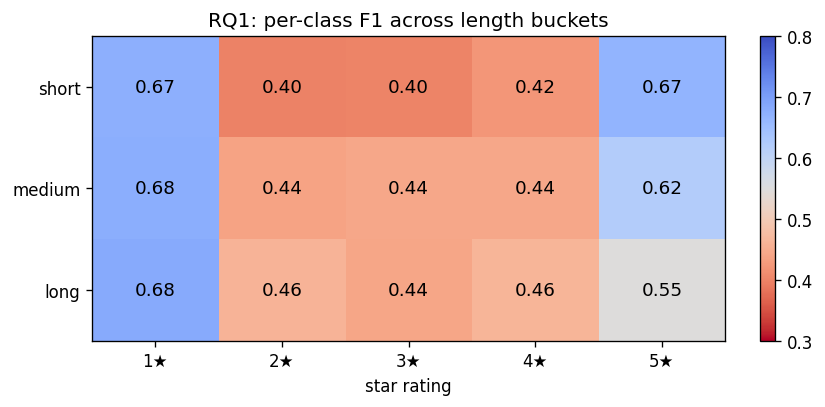

In [25]:
# heatmap
os.makedirs("assets", exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 3.5))
im = ax.imshow(f1_table.values, cmap="coolwarm_r", vmin=0.3, vmax=0.8, aspect="auto")
ax.set_xticks(range(5))
ax.set_xticklabels([f"{s}★" for s in f1_table.columns])
ax.set_yticks(range(3))
ax.set_yticklabels(f1_table.index)
ax.set_xlabel("star rating")
ax.set_title("RQ1: per-class F1 across length buckets")
for i in range(f1_table.shape[0]):
    for j in range(f1_table.shape[1]):
        ax.text(j, i, f"{f1_table.iat[i, j]:.2f}", ha="center", va="center", fontsize=11)
plt.colorbar(im, ax=ax, fraction=0.04)
plt.tight_layout()
plt.savefig("assets/rq1_length_heatmap.png", dpi=200, bbox_inches="tight")
plt.show()